# Archive QC

Quality control of the forecast/observation pairs accumulated in Neon by `scripts/log_forecast_obs.py`. No model is fitted here. The purpose is to establish whether the archive can support a learned forecast correction, and to document its limits before notebooks 02 and 03 depend on them.

Questions addressed:

1. Coverage of the archive in time, space, and forecast lead.
2. Whether the forecast error contains systematic structure beyond a constant offset.
3. Known defects: lead-time collapse in the table key, duplicate valid times, sparse stations.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import common

pairs = common.load_pairs()          # snapshots to artifacts/ on first pull
w = common.wide_pairs(pairs)         # one row per (station, valid_time), t2m error target
print(f"long rows: {len(pairs):,}   wide rows: {len(w):,}")
print(f"stations: {w.station_id.nunique()}   days: {w.local_date.nunique()}")
print(f"valid_time span: {w.forecast_valid_time.min()} .. {w.forecast_valid_time.max()}")

long rows: 127,569   wide rows: 42,533
stations: 164   days: 49
valid_time span: 2026-07-15 12:00:00+00:00 .. 2026-09-01 20:00:00+00:00


## 1. Schema and integrity

The table's uniqueness key is `(station_id, metric, forecast_valid_time)`. Forecast lead is not part of that key, so when two GFS cycles both cover a valid time, only the first-logged pair is retained. Each row's lead is therefore determined by workflow timing rather than by design. The cell below reports the lead distribution that resulted, and asserts that no (station, valid time) pair is duplicated after pivoting.

In [2]:
assert not w.duplicated(["station_id","forecast_valid_time"]).any(), "pivot produced duplicates"
lead_counts = w.lead_h.round().value_counts().sort_index()
print("surviving lead hours:")
print(lead_counts.to_string())
short = (w.lead_h <= 8).mean()
print(f"\n{short:.1%} of rows are lead <= 8h -> anything trained here is a SHORT-LEAD correction.")

surviving lead hours:
lead_h
0.0      8401
2.0     11984
4.0     11016
6.0      9837
8.0      1292
10.0        1
12.0        1
14.0        1

100.0% of rows are lead <= 8h -> anything trained here is a SHORT-LEAD correction.


Consequence: the archive supports correction of the 0 to 8 h portion of the forecast, which is the regime covered by the application's same-day panel and by the DA background. It provides no information about day-3 forecast skill. Extending to longer leads would require the reforecast archive held in git history and is outside the scope of these notebooks.

## 2. Coverage in time and space

Row counts per UTC day and per station, with a check for calendar gaps and for stations too sparse to support a per-station term.

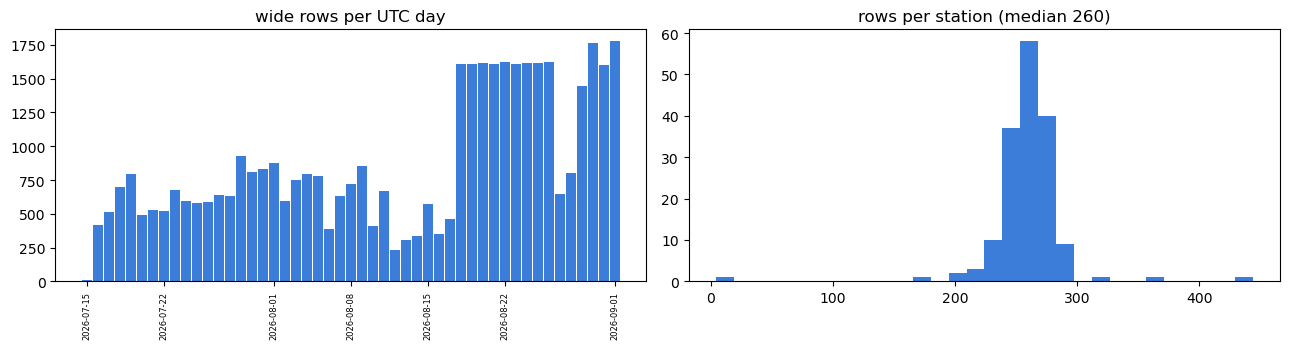

stations with <100 rows: 1 -> ['KADW']
calendar days with zero rows: 0


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
per_day = w.groupby(w.forecast_valid_time.dt.tz_convert("UTC").dt.date).size()
axes[0].bar(per_day.index, per_day.values, color="#3b7dd8", width=0.9)
axes[0].set_title("wide rows per UTC day"); axes[0].tick_params(axis="x", rotation=90, labelsize=6)

per_stn = w.groupby("station_id").size().sort_values()
axes[1].hist(per_stn, bins=30, color="#3b7dd8")
axes[1].set_title(f"rows per station (median {per_stn.median():.0f})")
plt.tight_layout(); plt.show()

thin = per_stn[per_stn < 100]
print(f"stations with <100 rows: {len(thin)}" + (f" -> {list(thin.index)}" if len(thin) else ""))
gap_days = pd.date_range(per_day.index.min(), per_day.index.max()).difference(pd.DatetimeIndex(per_day.index))
print(f"calendar days with zero rows: {len(gap_days)}" + (f" -> {[str(d.date()) for d in gap_days]}" if len(gap_days) else ""))

## 3. Error structure

Three diagnostics, computed before any model is fitted: the marginal error distribution, the diurnal cycle in station-local hour, and the spatial distribution of per-station mean bias.

Station-local hour is used rather than UTC hour. The diurnal error cycle is driven by the solar cycle, and 18 UTC corresponds to afternoon in the eastern CONUS and morning in the west, so pooling on UTC hour would attenuate the signal across time zones.

If these three diagnostics show no structure, a learned correction has no available signal and notebook 03 is not worth running.

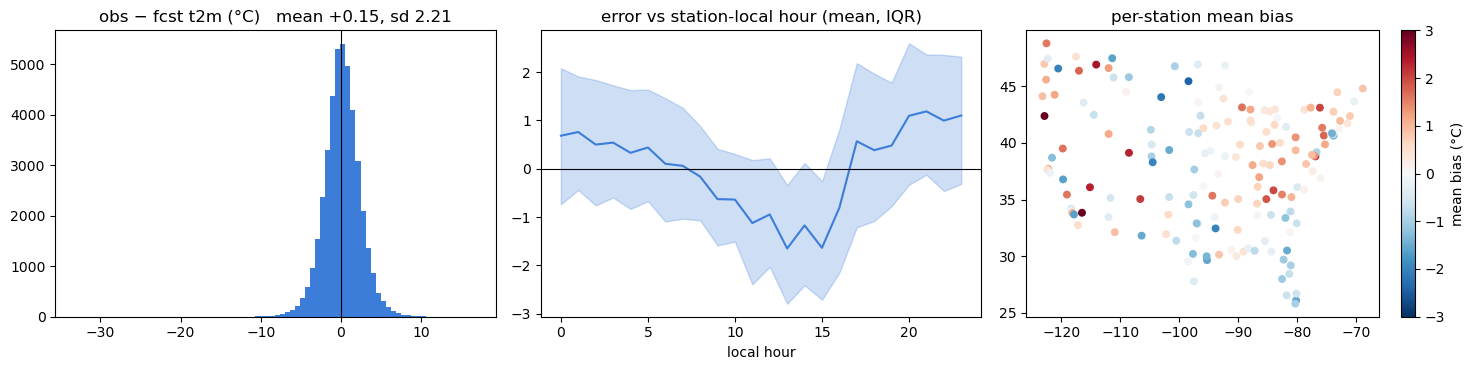

spread of per-station biases: sd 1.14°C, range -2.4 .. +4.8°C


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

axes[0].hist(w.err_t2m, bins=80, color="#3b7dd8")
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_title(f"obs − fcst t2m (°C)   mean {w.err_t2m.mean():+.2f}, sd {w.err_t2m.std():.2f}")

hb = w.groupby(w.local_hour.round())["err_t2m"].agg(["mean", lambda s: s.quantile(.25), lambda s: s.quantile(.75)])
hb.columns = ["mean","q25","q75"]
axes[1].fill_between(hb.index, hb.q25, hb.q75, alpha=.25, color="#3b7dd8")
axes[1].plot(hb.index, hb["mean"], color="#3b7dd8"); axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("error vs station-local hour (mean, IQR)"); axes[1].set_xlabel("local hour")

sb = w.groupby("station_id").agg(bias=("err_t2m","mean"), lat=("lat","first"), lon=("lon","first"))
sc = axes[2].scatter(sb.lon, sb.lat, c=sb.bias, cmap="RdBu_r", vmin=-3, vmax=3, s=22)
plt.colorbar(sc, ax=axes[2], label="mean bias (°C)")
axes[2].set_title("per-station mean bias")
plt.tight_layout(); plt.show()

print(f"spread of per-station biases: sd {sb.bias.std():.2f}°C, range {sb.bias.min():+.1f} .. {sb.bias.max():+.1f}°C")

## 4. Variance decomposition

Error variance removed by conditioning on the two cheapest available variables. This bounds what any correction can achieve, since a model can only remove the component predictable from its inputs.

In [5]:
total = common.rmse(w.err_t2m)
after_station = common.rmse(w.err_t2m - w.groupby("station_id").err_t2m.transform("mean"))
after_sh = common.rmse(w.err_t2m - w.groupby(["station_id", w.local_hour.round()]).err_t2m.transform("mean"))
tbl = pd.DataFrame({
    "rmse_C": [total, after_station, after_sh],
    "vs_raw": ["—", f"−{100*(1-after_station/total):.1f}%", f"−{100*(1-after_sh/total):.1f}%"],
}, index=["raw", "− station mean (in-sample)", "− station×local-hour mean (in-sample)"])
tbl.round(3)

,rmse_C,vs_raw
raw,2.216,—
− station mean (in-sample),1.901,−14.2%
− station×local-hour mean (in-sample),1.471,−33.6%


The values above are in-sample and are upper bounds rather than achievable skill. The station-by-hour cells contain approximately 10 observations each and are substantially overfitted. Out-of-sample estimates under a frozen split are established in notebook 02.

## Summary

1. The archive covers 49 days and 164 stations with no calendar gaps. One station (KADW) has fewer than 100 rows.
2. All rows have forecast lead at or below 8 h, a consequence of the table key documented in Section 1. All downstream claims are scoped accordingly.
3. The error contains systematic structure: per-station mean bias ranges from -2.4 to +4.8 °C with a standard deviation of 1.14 °C, and the diurnal cycle in station-local hour is coherent.

Proceed to notebook 02 (split definition and baselines) and notebook 03 (models).